# Linear Regression Optimization Techniques

This notebook provides a comprehensive implementation and comparison of various optimization strategies for Linear Regression. We explore:
1. **Stochastic Gradient Descent (SGD)**: High efficiency for large datasets.
2. **Batch Gradient Descent (BGD)**: Stable convergence using the full dataset.
3. **Regularized Linear Regression (Ridge)**: Incorporating L2 penalty to prevent overfitting.

# Stochastic gradient descent

In [1]:
def stochastic_gradient_descent(X, y, theta, alpha, num_iters):
  m = len(y)
  for _ in range(num_iters):
    rand_idx = np.random.randint(0, m)
    X_i = X[rand_idx:rand_idx+1]
    y_i = y[rand_idx:rand_idx+1]

    # Calculate hypothesis
    h = X_i.dot(theta)

    # Calculate error
    error = h - y_i

    # Update theta
    theta = theta - alpha * X_i.T.dot(error)
  return theta

In [2]:
def compute_cost(X, y, theta):
  m = len(y)
  predictions = X.dot(theta)
  cost = (1/(2*m)) * np.sum(np.square(predictions - y))
  return cost

Now, let's modify the `stochastic_gradient_descent` function to return the cost history so we can plot it.

In [3]:
# Modify the existing stochastic_gradient_descent function
def stochastic_gradient_descent(X, y, theta, alpha, num_iters):
  m = len(y)
  cost_history = []

  for _ in range(num_iters):
    rand_idx = np.random.randint(0, m)
    X_i = X[rand_idx:rand_idx+1]
    y_i = y[rand_idx:rand_idx+1]

    # Calculate hypothesis
    h = X_i.dot(theta)

    # Calculate error
    error = h - y_i

    # Update theta
    theta = theta - alpha * X_i.T.dot(error)

    # Record cost after each update
    cost_history.append(compute_cost(X, y, theta))

  return theta, cost_history

Let's generate some synthetic data and run the stochastic gradient descent to get the cost history.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias (intercept term) to X
X_b = np.c_[np.ones((100, 1)), X]

# Initialize parameters
theta = np.random.randn(2, 1) # Random initialization
alpha = 0.01  # Learning rate
num_iters = 1000 # Number of iterations

# Run Stochastic Gradient Descent
theta_optimized, cost_history = stochastic_gradient_descent(X_b, y, theta, alpha, num_iters)

print(f"Optimized Theta:\n{theta_optimized}")

Optimized Theta:
[[4.05682369]
 [3.14991819]]


Finally, let's plot the cost function history to see how the cost decreased over iterations.

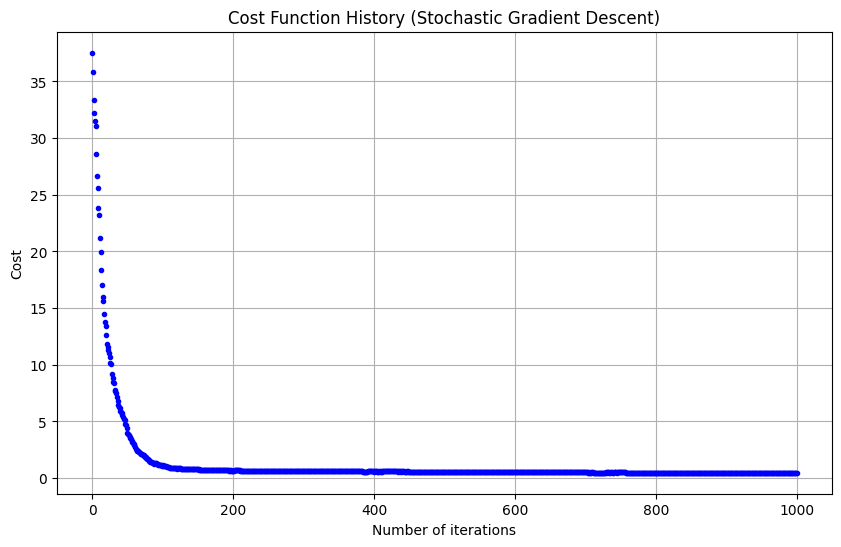

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_iters), cost_history, 'b.')
plt.xlabel('Number of iterations')
plt.ylabel('Cost')
plt.title('Cost Function History (Stochastic Gradient Descent)')
plt.grid(True)
plt.show()

## Comparing Stochastic Gradient Descent (SGD) with Batch Gradient Descent (BGD)

To compare SGD and BGD, let's first implement Batch Gradient Descent.

In [6]:
def batch_gradient_descent(X, y, theta, alpha, num_iters):
  m = len(y)
  cost_history = []

  for _ in range(num_iters):
    # Calculate hypothesis for the entire batch
    h = X.dot(theta)

    # Calculate error for the entire batch
    error = h - y

    # Update theta using the entire batch
    theta = theta - (alpha/m) * X.T.dot(error)

    # Record cost after each update
    cost_history.append(compute_cost(X, y, theta))

  return theta, cost_history

Now, let's run both Batch Gradient Descent (BGD) and Stochastic Gradient Descent (SGD) and compare their cost histories.

In [7]:
# Re-initialize parameters for a fair comparison
theta_initial = np.random.randn(2, 1) # Random initialization
alpha = 0.01  # Learning rate
num_iters = 1000 # Number of iterations

# Run Stochastic Gradient Descent
theta_sgd, cost_history_sgd = stochastic_gradient_descent(X_b, y, theta_initial.copy(), alpha, num_iters)

# Run Batch Gradient Descent
theta_bgd, cost_history_bgd = batch_gradient_descent(X_b, y, theta_initial.copy(), alpha, num_iters)

print(f"Optimized Theta (SGD):\n{theta_sgd}")
print(f"Optimized Theta (BGD):\n{theta_bgd}")

Optimized Theta (SGD):
[[4.22199112]
 [2.80802162]]
Optimized Theta (BGD):
[[4.22643219]
 [2.8733156 ]]


Let's plot the cost histories of both algorithms to visually compare their convergence.

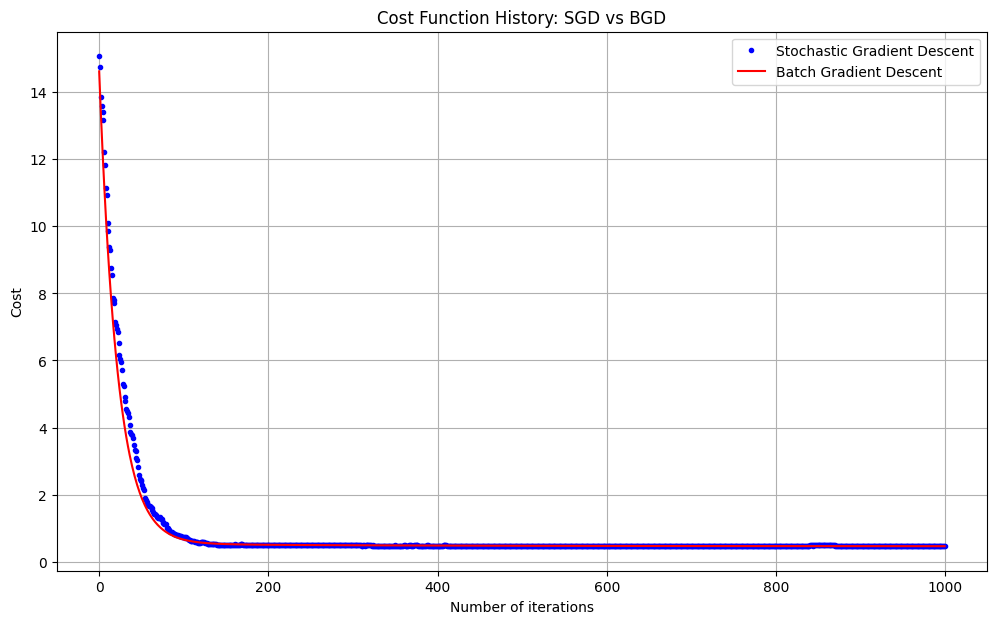

In [8]:
plt.figure(figsize=(12, 7))
plt.plot(range(num_iters), cost_history_sgd, 'b.', label='Stochastic Gradient Descent')
plt.plot(range(num_iters), cost_history_bgd, 'r-', label='Batch Gradient Descent')
plt.xlabel('Number of iterations')
plt.ylabel('Cost')
plt.title('Cost Function History: SGD vs BGD')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
def linear_regression_with_regularization(X, y, theta, alpha, num_iters, lambda_param):
  m = len(y)
  cost_history = []

  for _ in range(num_iters):
    # Calculate hypothesis
    h = X.dot(theta)

    # Calculate error
    error = h - y

    # Calculate gradient for theta (excluding bias term from regularization)
    gradient = (1/m) * X.T.dot(error)
    regularization_term = (lambda_param/m) * theta[1:] # Exclude bias term (theta[0])

    # Update theta_0 (bias term) separately
    theta[0] = theta[0] - alpha * gradient[0]
    # Update other theta terms with regularization
    theta[1:] = theta[1:] - alpha * (gradient[1:] + regularization_term)

    # Calculate regularized cost
    predictions = X.dot(theta)
    unregularized_cost = (1/(2*m)) * np.sum(np.square(predictions - y))
    regularization_cost = (lambda_param/(2*m)) * np.sum(np.square(theta[1:])) # Exclude bias term
    total_cost = unregularized_cost + regularization_cost
    cost_history.append(total_cost)

  return theta, cost_history

Now, let's run `linear_regression_with_regularization` with some sample data. We will use the same synthetic data `X_b` and `y` as before.

In [10]:
# Re-initialize parameters for regularization
theta_initial_reg = np.random.randn(2, 1) # Random initialization
alpha_reg = 0.01  # Learning rate
num_iters_reg = 1000 # Number of iterations
lambda_param = 0.1 # Regularization parameter (L2 regularization)

# Run Linear Regression with Regularization
theta_reg, cost_history_reg = linear_regression_with_regularization(X_b, y, theta_initial_reg.copy(), alpha_reg, num_iters_reg, lambda_param)

print(f"Optimized Theta (Regularized Linear Regression with lambda={lambda_param}):\n{theta_reg}")

Optimized Theta (Regularized Linear Regression with lambda=0.1):
[[4.09723991]
 [2.97469248]]


Let's plot the cost history for the regularized linear regression to see its convergence.

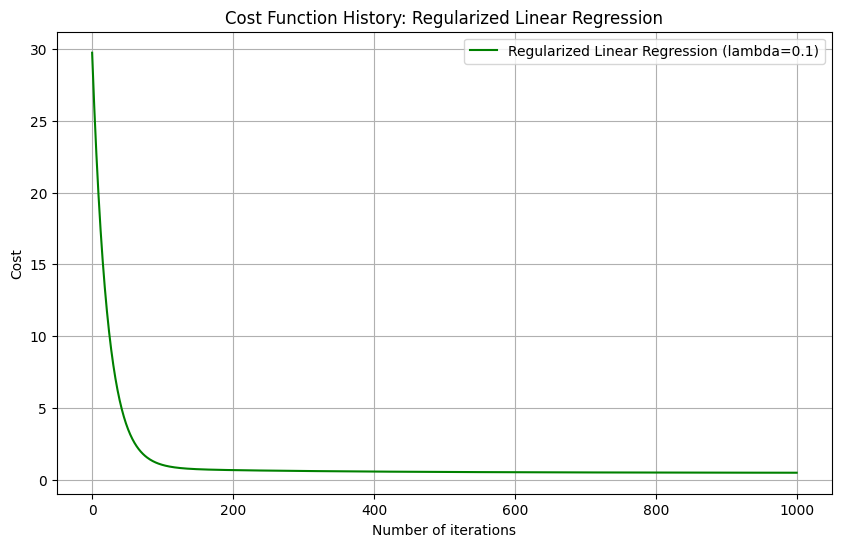

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_iters_reg), cost_history_reg, 'g-', label=f'Regularized Linear Regression (lambda={lambda_param})')
plt.xlabel('Number of iterations')
plt.ylabel('Cost')
plt.title('Cost Function History: Regularized Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

### Impact of the Regularization Parameter ($\lambda$)

The regularization parameter, $\lambda$, controls the trade-off between fitting the training data and keeping the model weights small:

1.  **Shrinkage Effect**: As $\lambda$ increases, the penalty for large weights grows. This forces the optimization to choose smaller values for $\theta_1, \theta_2, \dots, \theta_n$. You'll notice that the regularized $\theta$ values are typically closer to zero than the unregularized (BGD) values.
2.  **Bias-Variance Trade-off**:
    *   **Low $\lambda$**: High variance, low bias. The model might overfit by following the noise in the data.
    *   **High $\lambda$**: Low variance, high bias. The model is simpler and more robust to noise, but if $\lambda$ is too high, it might underfit (simplifying the model too much).
3.  **Bias Term**: Note that in our implementation (and standard practice), we do **not** regularize $\theta_0$ (the intercept). This ensures we don't penalize the model for having a baseline offset from the origin.

## Summary Comparison of All Methods

To conclude, let's visualize the convergence rates of Batch, Stochastic, and Regularized Gradient Descent models starting from the same initialization to see how regularization and update frequency impact training stability.

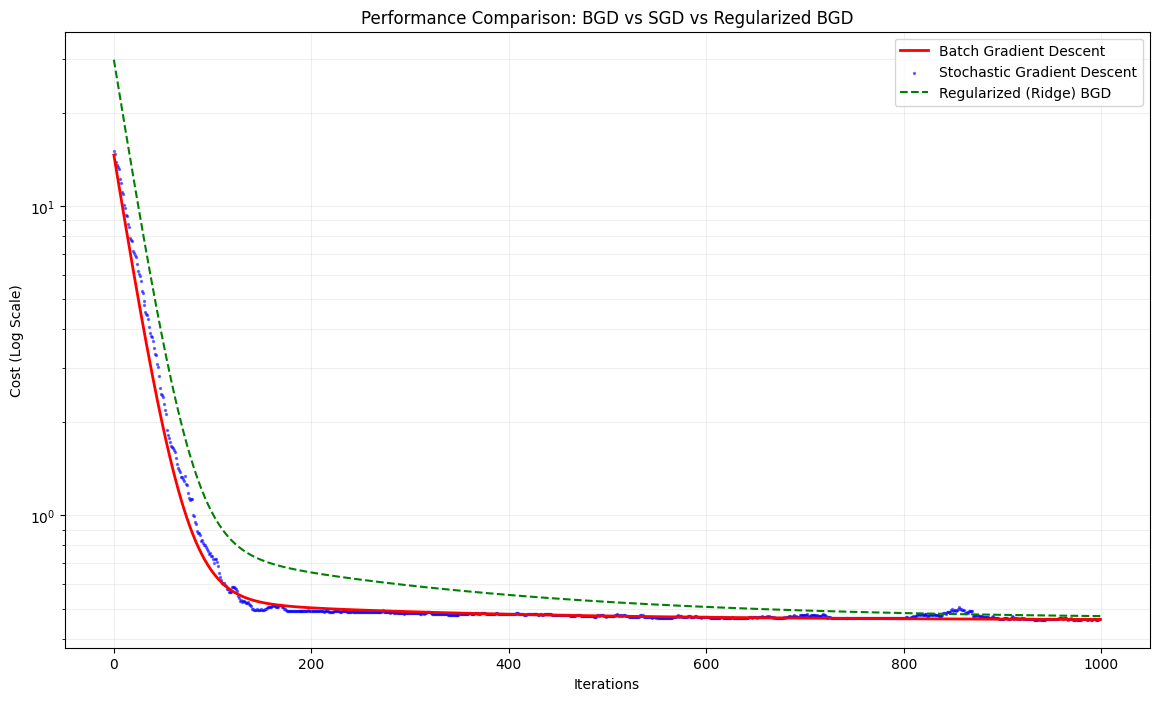

Final Comparisons:
BGD Final Cost: 0.4611
SGD Final Cost: 0.4634 (Note the noise)
Regularized Final Cost: 0.4727


In [12]:
plt.figure(figsize=(14, 8))

# Plotting all histories
plt.plot(range(len(cost_history_bgd)), cost_history_bgd, color='red', linewidth=2, label='Batch Gradient Descent')
plt.scatter(range(len(cost_history_sgd)), cost_history_sgd, color='blue', s=2, alpha=0.5, label='Stochastic Gradient Descent')
plt.plot(range(len(cost_history_reg)), cost_history_reg, color='green', linestyle='--', label='Regularized (Ridge) BGD')

plt.yscale('log') # Log scale helps visualize convergence when cost values vary widely
plt.xlabel('Iterations')
plt.ylabel('Cost (Log Scale)')
plt.title('Performance Comparison: BGD vs SGD vs Regularized BGD')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

print("Final Comparisons:")
print(f"BGD Final Cost: {cost_history_bgd[-1]:.4f}")
print(f"SGD Final Cost: {cost_history_sgd[-1]:.4f} (Note the noise)")
print(f"Regularized Final Cost: {cost_history_reg[-1]:.4f}")

### Visualizing the Sensitivity to Lambda ($\lambda$)

In this section, we compare the cost convergence curves for different regularization strengths. This helps in tuning the hyperparameter to find the right balance between bias and variance.

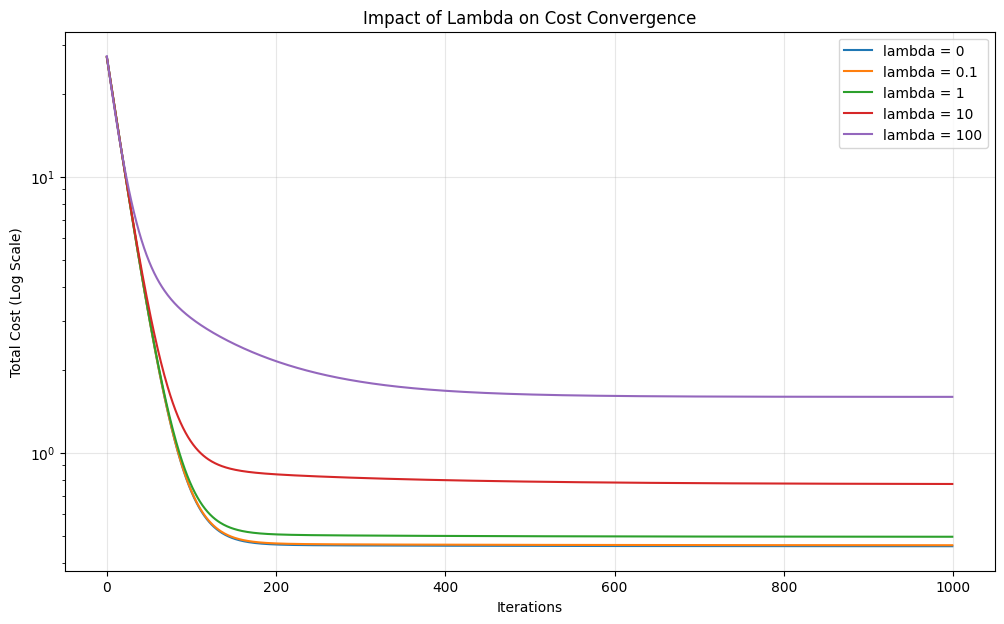

In [13]:
lambdas = [0, 0.1, 1, 10, 100]
plt.figure(figsize=(12, 7))

# Standardize initialization for fair comparison
theta_init_sensitivity = np.random.randn(2, 1)

for l in lambdas:
    _, cost_hist = linear_regression_with_regularization(
        X_b, y, theta_init_sensitivity.copy(), alpha_reg, num_iters_reg, l
    )
    plt.plot(range(len(cost_hist)), cost_hist, label=f'lambda = {l}')

plt.yscale('log')
plt.xlabel('Iterations')
plt.ylabel('Total Cost (Log Scale)')
plt.title('Impact of Lambda on Cost Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Numerical Comparison of $\theta$ Coefficients

The following table summarizes the final parameters obtained for different regularization strengths, demonstrating the shrinkage effect on the weights.

In [14]:
import pandas as pd

theta_results = []

for l in lambdas:
    t_optimized, _ = linear_regression_with_regularization(
        X_b, y, theta_init_sensitivity.copy(), alpha_reg, num_iters_reg, l
    )
    theta_results.append({
        'lambda': l,
        'theta_0 (intercept)': t_optimized[0][0],
        'theta_1 (slope)': t_optimized[1][0]
    })

df_comparison = pd.DataFrame(theta_results)
display(df_comparison)

,lambda,theta_0 (intercept),theta_1 (slope)
0,0.0,4.310632,2.806394
1,0.1,4.316250,2.800706
2,1.0,4.366037,2.750353
3,10.0,4.795855,2.319269
4,100.0,6.330781,0.834994
